In [19]:
import numpy as np
import matplotlib.pyplot as plt
import time as tm

In [20]:
def jacobi(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
            
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k
            
        x = x_new
        
    return x, max_iterations

In [21]:
def gauss_seidel(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()

    for k in range(max_iterations):
        x_new = x.copy()

        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i))
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n))
            x_new[i] = (b[i] - s1 - s2) / A[i][i]

        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k

        x = x_new

    return x, max_iterations

In [22]:
A = np.array([[3, -0.1, -0.2],[0.1, 7, -0.3],[0.3, -0.2, 10]])

b = np.array([7.85, -19.3, 71.4])



x0 = np.zeros_like(b)

tolerance_1 = 1e-3 

tolerance_2 = 1e-6 

tolerance_3 = 1e-9 

max_it = 100


sol_1, iterations_1 = jacobi(A, b, x0, tol1, max_it) #tolerance 1

sol_2, iterations_2 = jacobi(A, b, x0, tol2, max_it) #tolerance 2

sol_3, iterations_3 = jacobi(A, b, x0, tol3, max_it) #tolerance 3



print(f"jacobi: {solution1, solution2, solution3}")

print(f"iterations: {iterations1, iterations2, iterations3}")



sol_4, iterations_4 = gauss_seidel(A, b, x0, tol1, max_iterations) # tolerance 1

sol_5, iterations_5 = gauss_seidel(A, b, x0, tol2, max_iterations) # tolerance 2

sol_6, iterations_6 = gauss_seidel(A, b, x0, tol3, max_iterations) # tolerance 3



print(f"\n gauss-sedel solution: {sol_4, sol_5, sol_6}")

print(f"Iterations: {iterations_4, iterations_5, iterations_6}")

jacobi: (array([ 3.0000225 , -2.50000266,  6.99998104]), array([ 3. , -2.5,  7. ]), array([ 3. , -2.5,  7. ]))
iterations: (3, 6, 8)

 gauss-sedel solution: (array([ 3.00000035, -2.50000004,  6.99999999]), array([ 3. , -2.5,  7. ]), array([ 3. , -2.5,  7. ]))
Iterations: (3, 4, 6)


Using the tolerance of 1e-3, they both converged within 3 iterations due to the broadness of the tolerance. For 1e-6, jacobi converged in 6 while gauss-seidel converged quicker in 4. FOr the last one of tolerance 1e-9, jacobi converged in 8 while gauss-seidel converged in 6. The gauss seidel proved to be a better method as the tolerances got tighter

Text(0.5, 1.0, 'Total Absolute Error vs Iterations for gauss-seidel')

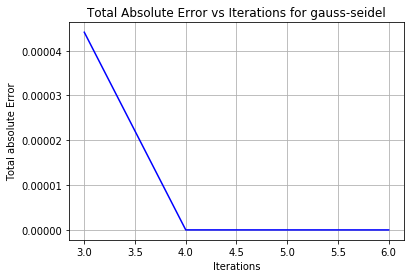

In [24]:
error_11 = np.abs(true_sol[0] - sol_1[0])

error_21 = np.abs(true_sol[1] - sol_1[1])

error_31 = np.abs(true_sol[2] - sol_1[2])

total_error_4 = error_11 + error_21 + error_31



error_12 = np.abs(true_sol[0] - sol_2[0])

error_22 = np.abs(true_sol[1] - sol_2[1])

error_32 = np.abs(true_sol[2] - sol_2[2])

total_error_5 = error_12 + error_22 + error_32



error_13 = np.abs(true_sol[0] - sol_3[0])

error_23 = np.abs(true_sol[1] - sol_3[1])

error_33 = np.abs(true_sol[2] - sol_3[2])

total_error_6 = error_13 + error_23 + error_33




error = [total_error_1, total_error_2, total_error_3]

iterations = [iterations_4, iterations_5, iterations_6]



plt.plot(iterations, error,'b-')
plt.ylabel("Total absolute Error")
plt.xlabel("Iterations")
plt.grid()
plt.title("Total Absolute Error vs Iterations for gauss-seidel")

Text(0.5, 1.0, 'Total Absolute Error vs Iterations for jacobi')

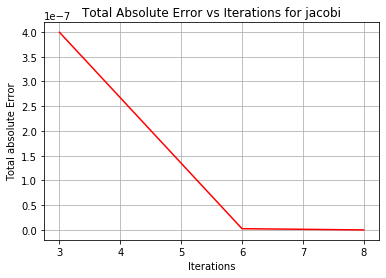

In [26]:
error_14 = np.abs(true_sol[0] - sol_4[0])

error_24 = np.abs(true_sol[1] - sol_4[1])

error_34 = np.abs(true_sol[2] - sol_4[2])

total_error_4 = error_14 + error_24 + error_34



error_15 = np.abs(true_sol[0] - sol_5[0])

error_25 = np.abs(true_sol[1] - sol_5[1])

error_35 = np.abs(true_sol[2] - sol_5[2])

total_error_5 = error_15 + error_25 + error_35



error_16 = np.abs(true_sol[0] - sol_6[0])

error_26 = np.abs(true_sol[1] - sol_6[1])

error_36 = np.abs(true_sol[2] - sol_6[2])

total_error_6 = error_16 + error_26 + error_36




error = [total_error_4, total_error_5, total_error_6]

iterations = [iterations_1, iterations_2, iterations_3]



plt.plot(iterations, error,'r-')
plt.ylabel("Total absolute Error")
plt.xlabel("Iterations")
plt.grid()
plt.title("Total Absolute Error vs Iterations for jacobi")

The tolerance used in each method plays a huge role in the number of iterations it takes to converge. THe tighter a tolerance is, the more the method has to iterate in order to find a solution within the given tolerance. The broadest tolerance of 1e-3 allowed both methods to converge very quickly since the tolerance was relatively open. As the tolerance tightened, the methods had to iterate more in order to find itself within the bounds of the tolerance.